In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

[OK] Đã nạp dữ liệu thành công!

--- BẢNG THỐNG KÊ ĐỘ CÂN BẰNG DATA ---
             Số lượng mẫu (Windows)  Tỷ lệ phần trăm (%)
Label                                                   
healthy                         500            33.333333
imbalance                       500            33.333333
obstruction                     500            33.333333
--------------------------------------


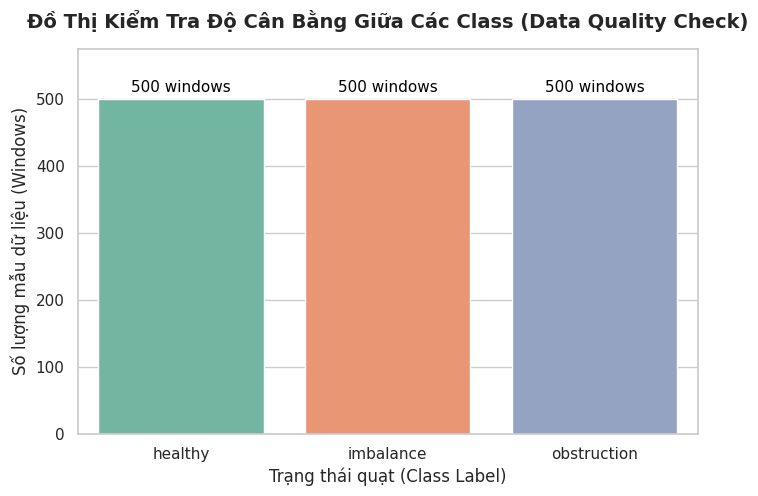

In [ ]:
# 1. Đọc file dữ liệu đặc trưng đã qua tiền xử lý
FILE_PATH = "dataset_features_for_ml.csv"

try:
    df = pd.read_csv(FILE_PATH)
    print("[OK] Đã nạp dữ liệu thành công!\n")

    # 2. Thống kê định lượng (Đếm số lượng mẫu của từng Class)
    class_counts = df['Label'].value_counts()
    class_percentages = df['Label'].value_counts(normalize=True) * 100

    # Tạo bảng tổng hợp để in ra màn hình
    summary_df = pd.DataFrame({
        'Số lượng mẫu (Windows)': class_counts,
        'Tỷ lệ phần trăm (%)': class_percentages
    })
    print("--- BẢNG THỐNG KÊ ĐỘ CÂN BẰNG DATA ---")
    print(summary_df.to_string())
    print("-" * 38)

    # 3. Trực quan hóa bằng Biểu đồ Cột (Bar Plot) để check Data Quality
    plt.figure(figsize=(8, 5))
    sns.set_theme(style="whitegrid") # Định dạng giao diện biểu đồ sạch sẽ, rõ ràng

    # Vẽ biểu đồ đếm số lượng
    ax = sns.countplot(x='Label', data=df, palette='Set2', hue='Label', legend=False)

    # Hiển thị số liệu chính xác trên đầu mỗi cột
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())} windows',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline',
                    fontsize=11, color='black',
                    xytext=(0, 5),
                    textcoords='offset points')

    plt.title('Đồ Thị Kiểm Tra Độ Cân Bằng Giữa Các Class (Data Quality Check)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Trạng thái quạt (Class Label)', fontsize=12)
    plt.ylabel('Số lượng mẫu dữ liệu (Windows)', fontsize=12)
    plt.ylim(0, max(class_counts) * 1.15) # Nới rộng trục Y để không bị đè chữ

    plt.show()

except FileNotFoundError:
    print(f"[LỖI] Không tìm thấy file '{FILE_PATH}'. Hãy chắc chắn rằng bạn đã chạy script tiền xử lý trước đó!")

[OK] Đã nạp dữ liệu thành công!



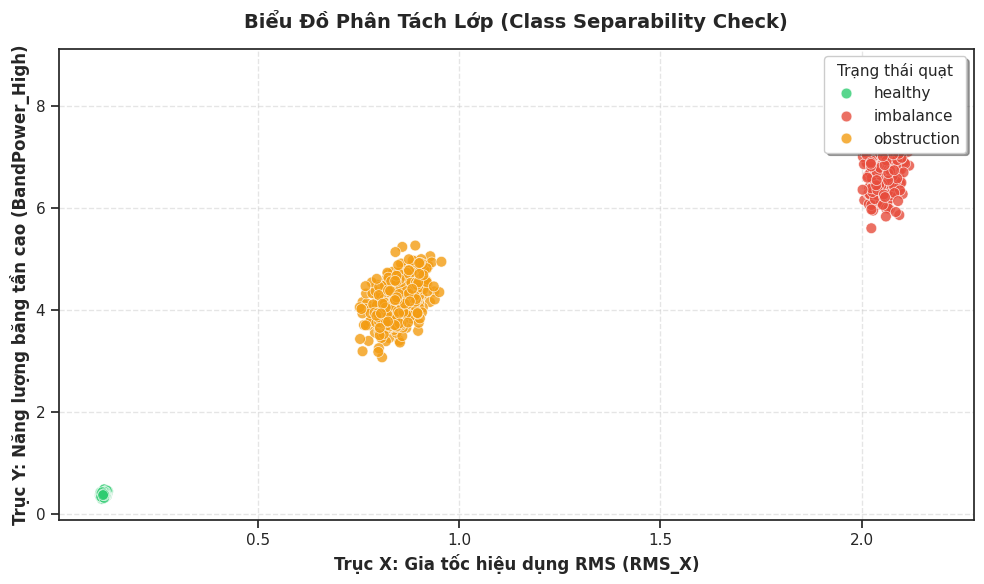

In [ ]:
try:
    df = pd.read_csv(FILE_PATH)
    print("[OK] Đã nạp dữ liệu thành công!\n")

    # 2. Cấu hình giao diện biểu đồ sạch sẽ, trực quan
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="ticks")

    # Định nghĩa bảng màu trực quan cho 3 trạng thái
    # Healthy: Xanh lá, Imbalance: Đỏ, Obstruction: Cam
    colors = {"healthy": "#2ecc71", "imbalance": "#e74c3c", "obstruction": "#f39c12"}

    # 3. Vẽ biểu đồ phân tán 2D (Scatter Plot)
    # Trục X: RMS_X (Bạn có thể đổi thành RMS_Y hoặc RMS_Z nếu cần)
    # Trục Y: BandPower_High
    sns.scatterplot(
        x='RMS_X',
        y='BandPower_High',
        hue='Label',
        data=df,
        palette=colors,
        alpha=0.8,      # Độ trong suốt để nhìn rõ các điểm chồng lấn
        s=60,           # Kích thước của mỗi điểm dữ liệu
        edgecolor='w',  # Viền trắng quanh điểm để tăng độ tương phản
        linewidth=0.5
    )

    # 4. Tinh chỉnh tiêu đề và nhãn trục theo chuẩn báo cáo kỹ thuật
    plt.title('Biểu Đồ Phân Tách Lớp (Class Separability Check)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Trục X: Gia tốc hiệu dụng RMS (RMS_X)', fontsize=12, fontweight='bold')
    plt.ylabel('Trục Y: Năng lượng băng tần cao (BandPower_High)', fontsize=12, fontweight='bold')

    # Tối ưu vị trí và định dạng của Legend (Bảng chú thích nhãn)
    plt.legend(title='Trạng thái quạt', title_fontsize='11', loc='upper right', frameon=True, shadow=True)

    # Hiển thị lưới mờ để dễ gióng tọa độ
    plt.grid(True, linestyle='--', alpha=0.5)

    # Hiển thị biểu đồ
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"[LỖI] Không tìm thấy file '{FILE_PATH}'. Hãy chạy script tiền xử lý dữ liệu trước!")

[OK] Đã nạp dữ liệu và đồng bộ chỉ số thời gian thành công!



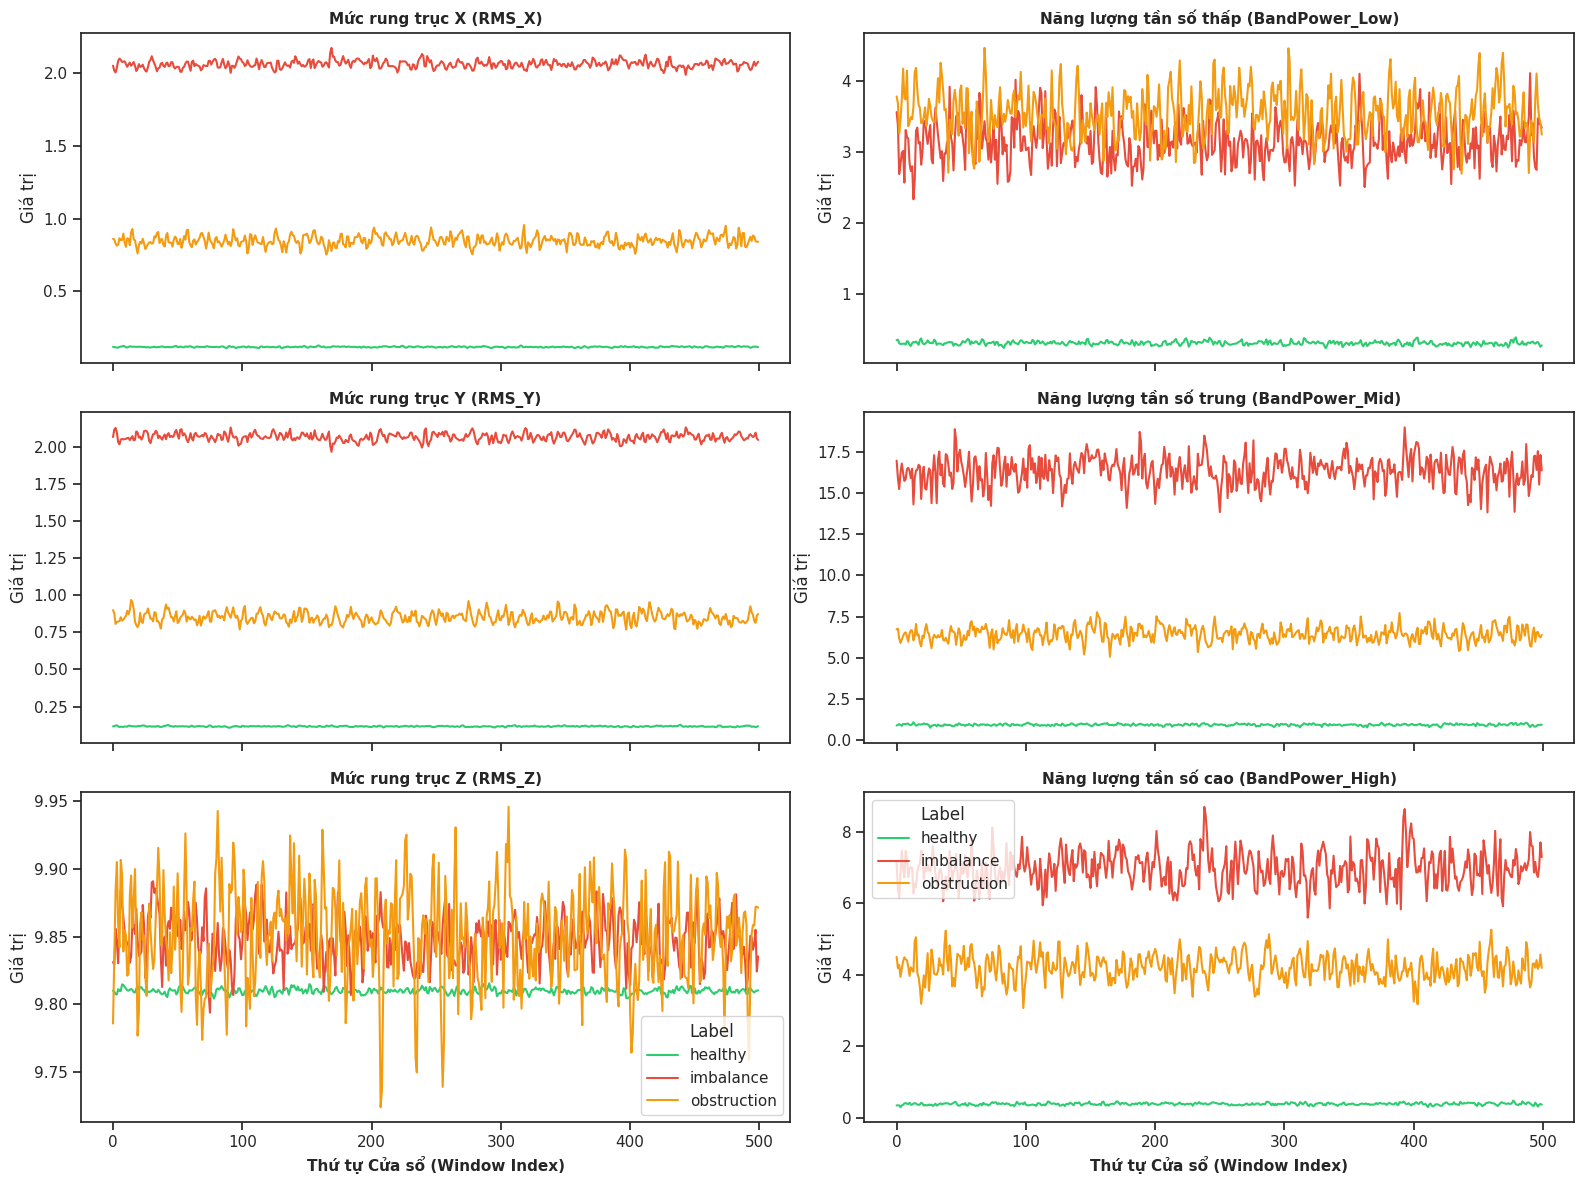

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu đặc trưng đã qua tiền xử lý
FILE_PATH = "dataset_features_for_ml.csv"

try:
    df = pd.read_csv(FILE_PATH)

    # Tạo chỉ số Window chạy từ 0 cho riêng từng Class để đồng bộ trục hoành (Thời gian)
    df['Window_Index'] = df.groupby('Label').cumcount()
    print("[OK] Đã nạp dữ liệu và đồng bộ chỉ số thời gian thành công!\n")

    # 2. Khởi tạo Grid đồ thị: 3 hàng (tương ứng 3 trục/băng tần), 2 cột (Cột 1: RMS, Cột 2: BandPower)
    fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)
    sns.set_theme(style="whitegrid")

    # Bảng màu nhất quán cho toàn hệ thống
    colors = {"healthy": "#2ecc71", "imbalance": "#e74c3c", "obstruction": "#f39c12"}

    # Danh sách các đặc trưng cần vẽ
    rms_features = ['RMS_X', 'RMS_Y', 'RMS_Z']
    bp_features = ['BandPower_Low', 'BandPower_Mid', 'BandPower_High']
    titles_rms = ['Mức rung trục X (RMS_X)', 'Mức rung trục Y (RMS_Y)', 'Mức rung trục Z (RMS_Z)']
    titles_bp = ['Năng lượng tần số thấp (BandPower_Low)', 'Năng lượng tần số trung (BandPower_Mid)', 'Năng lượng tần số cao (BandPower_High)']

    # 3. Vòng lặp vẽ tự động 6 đồ thị
    for i in range(3):
        # Cột 1: Vẽ các đặc trưng RMS
        sns.lineplot(
            data=df, x='Window_Index', y=rms_features[i], hue='Label',
            palette=colors, linewidth=1.5, ax=axes[i, 0]
        )
        axes[i, 0].set_title(titles_rms[i], fontsize=11, fontweight='bold')
        axes[i, 0].set_ylabel('Giá trị')
        # Ẩn bảng chú thích ở các hàng trên cho gọn, chỉ giữ lại ở hàng cuối
        if i < 2: axes[i, 0].get_legend().remove()

        # Cột 2: Vẽ các đặc trưng BandPower
        sns.lineplot(
            data=df, x='Window_Index', y=bp_features[i], hue='Label',
            palette=colors, linewidth=1.5, ax=axes[i, 1]
        )
        axes[i, 1].set_title(titles_bp[i], fontsize=11, fontweight='bold')
        axes[i, 1].set_ylabel('Giá trị')
        if i < 2: axes[i, 1].get_legend().remove()

    # Cấu hình nhãn trục hoành cho hàng cuối cùng
    axes[2, 0].set_xlabel('Thứ tự Cửa sổ (Window Index)', fontsize=11, fontweight='bold')
    axes[2, 1].set_xlabel('Thứ tự Cửa sổ (Window Index)', fontsize=11, fontweight='bold')

    # Tối ưu hóa khoảng cách hiển thị tránh đè chữ
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"[LỖI] Không tìm thấy file '{FILE_PATH}'. Hãy chạy script tiền xử lý trước!")

[OK] Đã nạp đầy đủ dữ liệu RAW liên tục thành công!

=== 1. KIỂM TRA HIỆN TƯỢNG CLIPPING (BÃO HÒA) ===
[HEALTHY] Biên độ đỉnh đạt -> X: 0.33, Y: 0.34, Z: 9.96 m/s^2
[IMBALANCE] Biên độ đỉnh đạt -> X: 3.95, Y: 4.03, Z: 11.58 m/s^2
[OBSTRUCTION] Biên độ đỉnh đạt -> X: 3.85, Y: 3.87, Z: 14.18 m/s^2
 -> [ĐẠT] Tín hiệu an toàn. Biên độ cực đại nằm dưới ngưỡng bão hòa 19.62 m/s^2.

=== 2. KIỂM TRA NỀN NHIỄU (NOISE FLOOR) & TỶ SỐ SNR ===
Công suất năng lượng dao động (Variance) trên trục X:
 - Trạng thái Healthy (Nền nhiễu cơ sở): 0.0137
 - Trạng thái Imbalance (Tín hiệu lỗi):  4.2565 -> Tỷ số SNR = 24.91 dB
 - Trạng thái Obstruction (Tín hiệu lỗi):0.7196 -> Tỷ số SNR = 17.19 dB
 -> [ĐẠT] Năng lượng trạng thái lỗi vượt trội rõ rệt so với nền nhiễu.
          Mô hình ML tuyến tính chắc chắn phân biệt được.



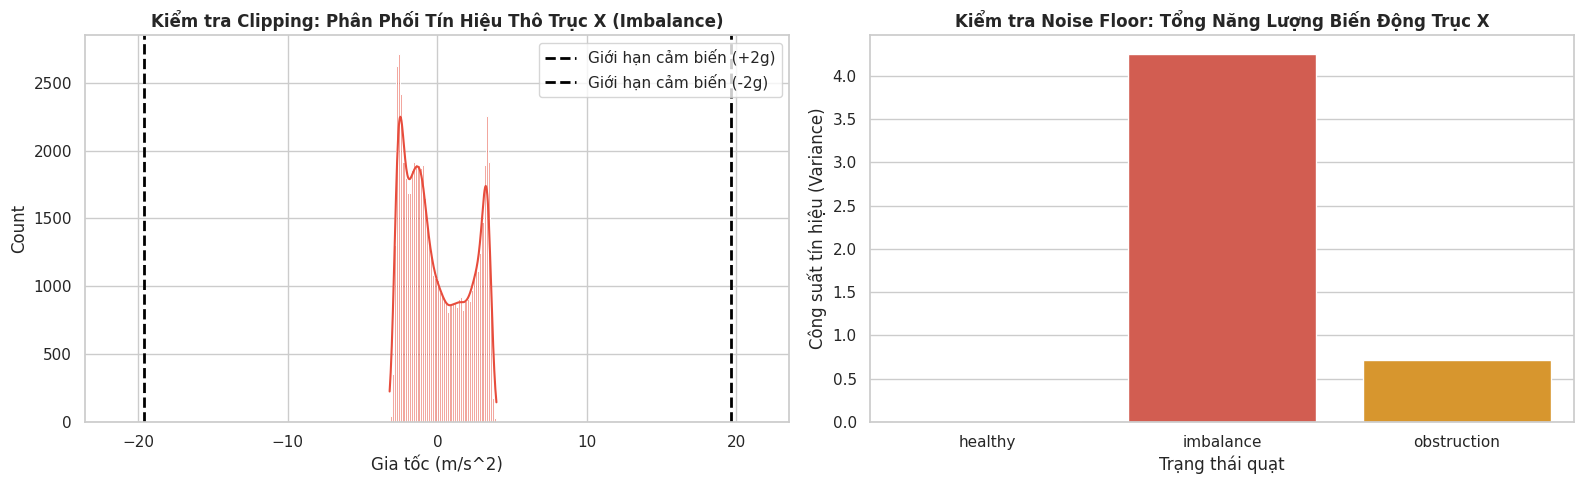

In [ ]:
RAW_DIR = "raw"
MPU6050_LIMIT = 2.0 * 9.81

classes = ["healthy", "imbalance", "obstruction"]
raw_data = {}

# 1. Nạp dữ liệu RAW liên tục từ Acquisition Team
for cls in classes:
    file_path = os.path.join(RAW_DIR, f"raw_stream_{cls}.csv")
    if os.path.exists(file_path):
        raw_data[cls] = pd.read_csv(file_path)
    else:
        print(f"[LỖI] Thiếu file dữ liệu thô: {file_path}")

if len(raw_data) == 3:
    print("[OK] Đã nạp đầy đủ dữ liệu RAW liên tục thành công!\n")

    # -----------------------------------------------------
    # BƯỚC 1: KIỂM TRA CLIPPING (BÃO HÒA ĐỈNH)
    # -----------------------------------------------------
    print("=== 1. KIỂM TRA HIỆN TƯỢNG CLIPPING (BÃO HÒA) ===")
    clipping_detected = False

    for cls in classes:
        df_raw = raw_data[cls]
        # Tìm giá trị tuyệt đối lớn nhất xuất hiện trong file dữ liệu thô của cả 3 trục
        max_x = np.max(np.abs(df_raw['accX']))
        max_y = np.max(np.abs(df_raw['accY']))
        max_z = np.max(np.abs(df_raw['accZ']))

        print(f"[{cls.upper()}] Biên độ đỉnh đạt -> X: {max_x:.2f}, Y: {max_y:.2f}, Z: {max_z:.2f} m/s^2")

        # Nếu biên độ đỉnh vượt quá dải đo 19.62 m/s^2, kích hoạt cảnh báo bão hòa
        if max_x >= MPU6050_LIMIT or max_y >= MPU6050_LIMIT or max_z >= MPU6050_LIMIT:
            print(f" -> [CẢNH BÁO] Tín hiệu chạm trần vật lý ({MPU6050_LIMIT:.2f} m/s^2). Dữ liệu bị cắt đỉnh!")
            clipping_detected = True

    if not clipping_detected:
        print(f" -> [ĐẠT] Tín hiệu an toàn. Biên độ cực đại nằm dưới ngưỡng bão hòa {MPU6050_LIMIT:.2f} m/s^2.\n")

    # -----------------------------------------------------
    # BƯỚC 2: KIỂM TRA NOISE FLOOR & TỶ SỐ SNR
    # -----------------------------------------------------
    print("=== 2. KIỂM TRA NỀN NHIỄU (NOISE FLOOR) & TỶ SỐ SNR ===")
    # Lấy phương sai (Variance) trục X làm đại diện cho công suất năng lượng biến động
    power_healthy = np.var(raw_data['healthy']['accX'])
    power_imbalance = np.var(raw_data['imbalance']['accX'])
    power_obstruction = np.var(raw_data['obstruction']['accX'])

    # Tính tỷ số Tín hiệu trên Nhiễu (SNR) theo đơn vị Decibel (dB)
    # Coi trạng thái 'healthy' là nền nhiễu cơ khí cơ bản kết hợp nhiễu nội tại cảm biến
    snr_imbalance_db = 10 * np.log10(power_imbalance / power_healthy)
    snr_obstruction_db = 10 * np.log10(power_obstruction / power_healthy)

    print(f"Công suất năng lượng dao động (Variance) trên trục X:")
    print(f" - Trạng thái Healthy (Nền nhiễu cơ sở): {power_healthy:.4f}")
    print(f" - Trạng thái Imbalance (Tín hiệu lỗi):  {power_imbalance:.4f} -> Tỷ số SNR = {snr_imbalance_db:.2f} dB")
    print(f" - Trạng thái Obstruction (Tín hiệu lỗi):{power_obstruction:.4f} -> Tỷ số SNR = {snr_obstruction_db:.2f} dB")

    # Tiêu chuẩn công nghiệp: SNR > 10dB cho lỗi nặng và > 3dB cho lỗi nhẹ là đạt yêu cầu phân tách
    if snr_imbalance_db > 10 and snr_obstruction_db > 3:
        print(" -> [ĐẠT] Năng lượng trạng thái lỗi vượt trội rõ rệt so với nền nhiễu.")
        print("          Mô hình ML tuyến tính chắc chắn phân biệt được.\n")
    else:
        print(" -> [CẢNH BÁO] Tín hiệu lỗi quá yếu, có nguy cơ bị nuốt bởi nền nhiễu!\n")

    # -----------------------------------------------------
    # BƯỚC 3: TRỰC QUAN HÓA BẰNG ĐỒ THỊ KIỂM ĐỊNH
    # -----------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    sns.set_theme(style="whitegrid")

    # Biểu đồ 1: Biểu đồ phân phối mật độ (Histogram) để xem có bị bão hòa phẳng đỉnh hay không
    sns.histplot(raw_data['imbalance']['accX'], ax=ax1, color='#e74c3c', kde=True, bins=50)
    ax1.axvline(x=MPU6050_LIMIT, color='black', linestyle='--', linewidth=2, label='Giới hạn cảm biến (+2g)')
    ax1.axvline(x=-MPU6050_LIMIT, color='black', linestyle='--', linewidth=2, label='Giới hạn cảm biến (-2g)')
    ax1.set_title('Kiểm tra Clipping: Phân Phối Tín Hiệu Thô Trục X (Imbalance)', fontweight='bold')
    ax1.set_xlabel('Gia tốc (m/s^2)')
    ax1.set_xlim(-MPU6050_LIMIT * 1.2, MPU6050_LIMIT * 1.2)
    ax1.legend()

    # Biểu đồ 2: So sánh công suất năng lượng để kiểm tra khoảng cách với Noise Floor
    energies = [power_healthy, power_imbalance, power_obstruction]
    sns.barplot(x=classes, y=energies, palette=['#2ecc71', '#e74c3c', '#f39c12'], ax=ax2, hue=classes, legend=False)
    ax2.set_title('Kiểm tra Noise Floor: Tổng Năng Lượng Biến Động Trục X', fontweight='bold')
    ax2.set_ylabel('Công suất tín hiệu (Variance)')
    ax2.set_xlabel('Trạng thái quạt')

    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Load file đặc trưng đã xử lý
df = pd.read_csv("dataset_features_for_ml.csv")

# Tách Feature (X) và Label (y)
X = df.drop('Label', axis=1)
y = df['Label']

# Tách ngẫu nhiên theo tỷ lệ 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tổng số mẫu: {len(df)}")
print(f"Mẫu để Train: {len(X_train)}")
print(f"Mẫu để Test (Validation): {len(X_test)}")

Tổng số mẫu: 1500
Mẫu để Train: 1200
Mẫu để Test (Validation): 300


--- THÔNG SỐ CHUẨN HÓA ĐỂ LƯU VÀO MCU ---
Feature 'RMS_X' -> Mean: 1.0260, Std: 0.8091
Feature 'RMS_Y' -> Mean: 1.0279, Std: 0.8100
Feature 'RMS_Z' -> Mean: 9.8370, Std: 0.0288
Feature 'BandPower_Low' -> Mean: 2.3412, Std: 1.4593
Feature 'BandPower_Mid' -> Mean: 8.0621, Std: 6.4538
Feature 'BandPower_High' -> Mean: 3.8972, Std: 2.7282

--- BÁO CÁO HIỆU NĂNG MÔ HÌNH ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00       104
   imbalance       1.00      1.00      1.00        86
 obstruction       1.00      1.00      1.00       110

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300




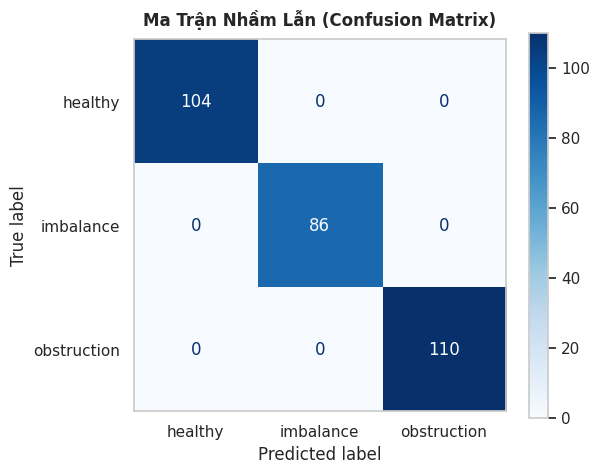

In [ ]:
# =========================================================
# 1. FEATURE SCALING (CHUẨN HÓA DỮ LIỆU)
# =========================================================
# Khởi tạo bộ chuẩn hóa Z-score (StandardScaler)
scaler = StandardScaler()

# Tính toán Mean và Std dựa trên tập Train và biến đổi dữ liệu
X_train_scaled = scaler.fit_transform(X_train)

# CHỈ biến đổi tập Test dựa trên Mean và Std của tập Train (Không fit lại!)
X_test_scaled = scaler.transform(X_test)

print("--- THÔNG SỐ CHUẨN HÓA ĐỂ LƯU VÀO MCU ---")
for i, col in enumerate(X.columns):
    print(f"Feature '{col}' -> Mean: {scaler.mean_[i]:.4f}, Std: {scaler.scale_[i]:.4f}")
print("=========================================\n")

# =========================================================
# 2. TRAIN MODEL BASELINE (LOGISTIC REGRESSION)
# =========================================================
# Khởi tạo mô hình phân loại đa lớp
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)

# Huấn luyện mô hình trên dữ liệu đã chuẩn hóa
model.fit(X_train_scaled, y_train)

# =========================================================
# 3. ĐÁNH GIÁ MÔ HÌNH (EVALUATION)
# =========================================================
# Dự đoán trên tập Test
y_pred = model.predict(X_test_scaled)

# In báo cáo chi tiết (Precision, Recall, F1-score)
print("--- BÁO CÁO HIỆU NĂNG MÔ HÌNH ---")
print(classification_report(y_test, y_pred))
print("=================================\n")

# Vẽ Confusion Matrix (Ma trận nhầm lẫn) để nộp báo cáo
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Ma Trận Nhầm Lẫn (Confusion Matrix)", fontweight='bold', pad=10)
plt.grid(False)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import os
import time

# =========================================================
# 1. CẤU HÌNH PIPELINE REAL-TIME (Phải khớp hoàn toàn với tập Train)
# =========================================================
WINDOW_SIZE = 256
STRIDE = 128
TEST_DIR = "test"
classes = ["healthy", "imbalance", "obstruction"]

def extract_features_from_window(w_x, w_y, w_z):
    """Hàm trích xuất đặc trưng (Sao chép chính xác từ pha Preprocessing)"""
    rms_x = np.sqrt(np.mean(w_x**2))
    rms_y = np.sqrt(np.mean(w_y**2))
    rms_z = np.sqrt(np.mean(w_z**2))

    fft_x = np.abs(np.fft.rfft(w_x))
    band_low = np.sum(fft_x[0:38]) / 100
    band_mid = np.sum(fft_x[38:83]) / 100
    band_high = np.sum(fft_x[83:128]) / 100

    return [rms_x, rms_y, rms_z, band_low, band_mid, band_high]

# =========================================================
# 2. CHẠY DEMO MÔ PHỎNG TRÊN TỪNG STREAM FILE
# =========================================================
print("============= KHỞI ĐỘNG HỆ THỐNG TINYML DEMO =============")
print("Trạng thái Model: Đã sẵn sàng.")
print("Trạng thái Scaler: Đã khóa hằng số Mean/Std.\n")

for cls in classes:
    file_name = f"test_stream_{cls}.csv"
    file_path = os.path.join(TEST_DIR, file_name)

    if not os.path.exists(file_path):
        print(f"[BỎ QUA] Không tìm thấy file test: {file_path}")
        continue

    print(f" Đang nạp luồng dữ liệu thực tế: '{file_name}'")
    print("-" * 60)

    # Đọc file test raw stream
    df_test = pd.read_csv(file_path)
    accX = df_test['accX'].values
    accY = df_test['accY'].values
    accZ = df_test['accZ'].values

    num_samples = len(df_test)
    start_idx = 0
    window_count = 0
    correct_predictions = 0

    # Mô phỏng vòng lặp vô hạn đọc cảm biến trên MCU
    while (start_idx + WINDOW_SIZE) <= num_samples:
        # Cắt một cửa sổ dữ liệu thực tế
        w_x = accX[start_idx : start_idx + WINDOW_SIZE]
        w_y = accY[start_idx : start_idx + WINDOW_SIZE]
        w_z = accZ[start_idx : start_idx + WINDOW_SIZE]

        # Bước 1: Tiền xử lý (Trích xuất đặc trưng thô)
        raw_features = extract_features_from_window(w_x, w_y, w_z)

        # Bước 2: Chuẩn hóa dữ liệu sử dụng Scaler đã train trước đó
        # (Ép kiểu về 2D array để tương thích với Scikit-learn)
        scaled_features = scaler.transform([raw_features])

        # Bước 3: Mô hình ML thực hiện Inference (Dự đoán)
        prediction = model.predict(scaled_features)[0]

        # Tính toán xác suất (Độ tự tin của mô hình)
        probabilities = model.predict_proba(scaled_features)[0]
        confidence = np.max(probabilities) * 100

        # Thống kê độ chính xác của buổi demo
        window_count += 1
        if prediction == cls:
            correct_predictions += 1

        # In kết quả dạng Stream (Mô phỏng LED hoặc Monitor ngoài thực tế)
        timestamp_sec = (start_idx + WINDOW_SIZE) * (1.0 / 200) # fs = 200Hz
        print(f"Time: {timestamp_sec:6.2f}s | Window #{window_count:03d} | Predicted: {prediction.upper():12} ({confidence:5.1f}% confidence)")

        # Tịnh tiến cửa sổ theo đúng bước nhảy Stride (128 mẫu = 0.64s)
        start_idx += STRIDE

    # Tổng kết hiệu năng của luồng dữ liệu vừa chạy
    accuracy = (correct_predictions / window_count) * 100 if window_count > 0 else 0
    print("-" * 60)
    print(f" kết quả file '{file_name}': Đúng {correct_predictions}/{window_count} windows | Độ chính xác Demo: {accuracy:.2f}%\n")

print("================ CHƯƠNG TRÌNH DEMO KẾT THÚC ================")

============= KHỞI ĐỘNG HỆ THỐNG TINYML DEMO =============
Trạng thái Model: Đã sẵn sàng.
Trạng thái Scaler: Đã khóa hằng số Mean/Std.

 Đang nạp luồng dữ liệu thực tế: 'test_stream_healthy.csv'
------------------------------------------------------------
Time:   1.28s | Window #001 | Predicted: HEALTHY      ( 99.8% confidence)
Time:   1.92s | Window #002 | Predicted: HEALTHY      ( 99.8% confidence)
Time:   2.56s | Window #003 | Predicted: HEALTHY      ( 99.8% confidence)
Time:   3.20s | Window #004 | Predicted: HEALTHY      ( 99.8% confidence)
Time:   3.84s | Window #005 | Predicted: HEALTHY      ( 99.8% confidence)
Time:   4.48s | Window #006 | Predicted: HEALTHY      ( 99.7% confidence)
Time:   5.12s | Window #007 | Predicted: HEALTHY      ( 99.7% confidence)
Time:   5.76s | Window #008 | Predicted: HEALTHY      ( 99.8% confidence)
Time:   6.40s | Window #009 | Predicted: HEALTHY      ( 99.7% confidence)
Time:   7.04s | Window #010 | Predicted: HEALTHY      ( 99.7% confidence)
Time

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Time:  21.76s | Window #033 | Predicted: HEALTHY      ( 99.8% confidence)
Time:  22.40s | Window #034 | Predicted: HEALTHY      ( 99.8% confidence)
Time:  23.04s | Window #035 | Predicted: HEALTHY      ( 99.8% confidence)
Time:  23.68s | Window #036 | Predicted: HEALTHY      ( 99.7% confidence)
Time:  24.32s | Window #037 | Predicted: HEALTHY      ( 99.8% confidence)
Time:  24.96s | Window #038 | Predicted: HEALTHY      ( 99.8% confidence)
Time:  25.60s | Window #039 | Predicted: HEALTHY      ( 99.8% confidence)
Time:  26.24s | Window #040 | Predicted: HEALTHY      ( 99.8% confidence)
Time:  26.88s | Window #041 | Predicted: HEALTHY      ( 99.7% confidence)
Time:  27.52s | Window #042 | Predicted: HEALTHY      ( 99.8% confidence)
Time:  28.16s | Window #043 | Predicted: HEALTHY      ( 99.8% confidence)
Time:  28.80s | Window #044 | Predicted: HEALTHY      ( 99.8% confidence)
Time:  29.44s | Window #045 | Predicted: HEALTHY      ( 99.8% confidence)
Time:  30.08s | Window #046 | Predicte

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Time: 128.64s | Window #200 | Predicted: HEALTHY      ( 99.8% confidence)
Time: 129.28s | Window #201 | Predicted: HEALTHY      ( 99.8% confidence)
Time: 129.92s | Window #202 | Predicted: HEALTHY      ( 99.8% confidence)
Time: 130.56s | Window #203 | Predicted: HEALTHY      ( 99.7% confidence)
Time: 131.20s | Window #204 | Predicted: HEALTHY      ( 99.8% confidence)
Time: 131.84s | Window #205 | Predicted: HEALTHY      ( 99.8% confidence)
Time: 132.48s | Window #206 | Predicted: HEALTHY      ( 99.7% confidence)
Time: 133.12s | Window #207 | Predicted: HEALTHY      ( 99.7% confidence)
Time: 133.76s | Window #208 | Predicted: HEALTHY      ( 99.7% confidence)
Time: 134.40s | Window #209 | Predicted: HEALTHY      ( 99.8% confidence)
Time: 135.04s | Window #210 | Predicted: HEALTHY      ( 99.8% confidence)
Time: 135.68s | Window #211 | Predicted: HEALTHY      ( 99.8% confidence)
Time: 136.32s | Window #212 | Predicted: HEALTHY      ( 99.8% confidence)
Time: 136.96s | Window #213 | Predicte

...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Time: 289.92s | Window #452 | Predicted: IMBALANCE    ( 99.8% confidence)
Time: 290.56s | Window #453 | Predicted: IMBALANCE    ( 99.8% confidence)
Time: 291.20s | Window #454 | Predicted: IMBALANCE    ( 99.8% confidence)
Time: 291.84s | Window #455 | Predicted: IMBALANCE    ( 99.6% confidence)
Time: 292.48s | Window #456 | Predicted: IMBALANCE    ( 99.8% confidence)
Time: 293.12s | Window #457 | Predicted: IMBALANCE    ( 99.8% confidence)
Time: 293.76s | Window #458 | Predicted: IMBALANCE    ( 99.6% confidence)
Time: 294.40s | Window #459 | Predicted: IMBALANCE    ( 99.5% confidence)
Time: 295.04s | Window #460 | Predicted: IMBALANCE    ( 99.7% confidence)
Time: 295.68s | Window #461 | Predicted: IMBALANCE    ( 99.7% confidence)
Time: 296.32s | Window #462 | Predicted: IMBALANCE    ( 99.8% confidence)
Time: 296.96s | Window #463 | Predicted: IMBALANCE    ( 99.9% confidence)
Time: 297.60s | Window #464 | Predicted: IMBALANCE    ( 99.6% confidence)
Time: 298.24s | Window #465 | Predicte

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Time:   1.28s | Window #001 | Predicted: OBSTRUCTION  ( 97.1% confidence)
Time:   1.92s | Window #002 | Predicted: OBSTRUCTION  ( 98.0% confidence)
Time:   2.56s | Window #003 | Predicted: OBSTRUCTION  ( 99.5% confidence)
Time:   3.20s | Window #004 | Predicted: OBSTRUCTION  ( 98.4% confidence)
Time:   3.84s | Window #005 | Predicted: OBSTRUCTION  ( 99.3% confidence)
Time:   4.48s | Window #006 | Predicted: OBSTRUCTION  ( 99.6% confidence)
Time:   5.12s | Window #007 | Predicted: OBSTRUCTION  ( 99.7% confidence)
Time:   5.76s | Window #008 | Predicted: OBSTRUCTION  ( 99.9% confidence)
Time:   6.40s | Window #009 | Predicted: OBSTRUCTION  ( 99.7% confidence)
Time:   7.04s | Window #010 | Predicted: OBSTRUCTION  ( 99.2% confidence)
Time:   7.68s | Window #011 | Predicted: OBSTRUCTION  ( 99.7% confidence)
Time:   8.32s | Window #012 | Predicted: OBSTRUCTION  ( 99.9% confidence)
Time:   8.96s | Window #013 | Predicted: OBSTRUCTION  ( 99.8% confidence)
Time:   9.60s | Window #014 | Predicte

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Đang huấn luyện mạng Small Dense Neural Network...
[OK] Mạng Nơ-ron đã học xong!

--- BÁO CÁO HIỆU NĂNG NEURAL NETWORK ---
              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00       104
   imbalance       1.00      1.00      1.00        86
 obstruction       1.00      1.00      1.00       110

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300


--- KIỂM TRA CẤU TRÚC MA TRẬN ĐỂ VIẾT CODE C++ ---
Tuyến 1 (Tầng 1 -> Tầng 2):
  - Cấu hình Weights Matrix W1: (6, 16) (96 hằng số)
  - Cấu hình Biases Vector  b1: (16,) (16 hằng số)
Tuyến 2 (Tầng 2 -> Tầng 3):
  - Cấu hình Weights Matrix W2: (16, 8) (128 hằng số)
  - Cấu hình Biases Vector  b2: (8,) (8 hằng số)
Tuyến 3 (Tầng 3 -> Tầng 4):
  - Cấu hình Weights Matrix W3: (8, 3) (24 hằng số)
  - Cấu hình Biases Vector  b3: (3,) (3 hằng số)



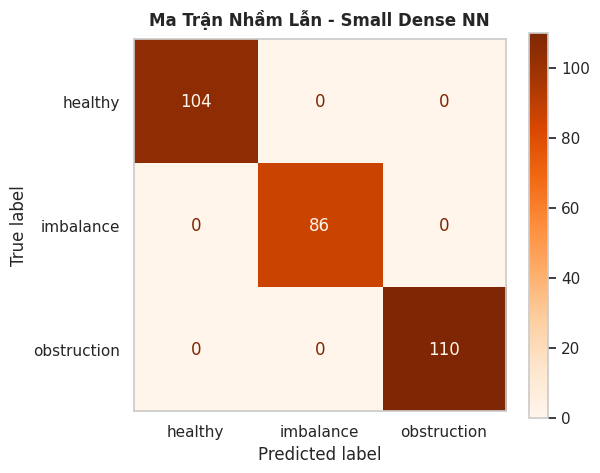

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Giả định các biến X_train_scaled, X_test_scaled, y_train, y_test
# đã được khởi tạo và lưu trong RAM từ cell chuẩn hóa trước đó.

# =========================================================
# 1. KHỞI TẠO KIẾN TRÚC MẠNG SMALL DENSE NN
# =========================================================
# hidden_layer_sizes=(16, 8) cấu hình đúng 2 tầng ẩn có 16 và 8 nút
# activation='relu' là hàm kích hoạt phi tuyến cho các tầng ẩn
mlp_model = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

# =========================================================
# 2. HUẤN LUYỆN (TRAINING)
# =========================================================
print("Đang huấn luyện mạng Small Dense Neural Network...")
mlp_model.fit(X_train_scaled, y_train)
print("[OK] Mạng Nơ-ron đã học xong!\n")

# =========================================================
# 3. ĐÁNH GIÁ MÔ HÌNH (EVALUATION)
# =========================================================
y_pred_mlp = mlp_model.predict(X_test_scaled)

print("--- BÁO CÁO HIỆU NĂNG NEURAL NETWORK ---")
print(classification_report(y_test, y_pred_mlp))
print("=========================================\n")

# =========================================================
# 4. KIỂM TRA ĐỘ LỚN THAM SỐ ĐỂ CHUẨN BỊ LÊN MCU
# =========================================================
print("--- KIỂM TRA CẤU TRÚC MA TRẬN ĐỂ VIẾT CODE C++ ---")
# coefs_ chứa các ma trận trọng số (Weights)
# intercepts_ chứa các mảng độ lệch (Biases)
for i in range(len(mlp_model.coefs_)):
    W_shape = mlp_model.coefs_[i].shape
    b_shape = mlp_model.intercepts_[i].shape
    print(f"Tuyến {i+1} (Tầng {i+1} -> Tầng {i+2}):")
    print(f"  - Cấu hình Weights Matrix W{i+1}: {W_shape} ({W_shape[0] * W_shape[1]} hằng số)")
    print(f"  - Cấu hình Biases Vector  b{i+1}: {b_shape} ({b_shape[0]} hằng số)")
print("==================================================\n")

# =========================================================
# 5. VẼ CONFUSION MATRIX
# =========================================================
fig, ax = plt.subplots(figsize=(6, 5))
cm_mlp = confusion_matrix(y_test, y_pred_mlp, labels=mlp_model.classes_)
disp_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=mlp_model.classes_)
disp_mlp.plot(cmap=plt.cm.Oranges, ax=ax)
plt.title("Ma Trận Nhầm Lẫn - Small Dense NN", fontweight='bold', pad=10)
plt.grid(False)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import os

# =========================================================
# 1. CẤU HÌNH REAL-TIME PIPELINE (Đồng bộ tuyệt đối với pha Train)
# =========================================================
WINDOW_SIZE = 256
STRIDE = 128
SAMPLING_RATE = 200  # Hz
TEST_DIR = "test"    # Thư mục chứa các file test stream bạn đã tải lên
classes = ["healthy", "imbalance", "obstruction"]

def extract_features_from_window(w_x, w_y, w_z):
    """Bộ trích xuất đặc trưng cơ bản (RMS + BandPower)"""
    rms_x = np.sqrt(np.mean(w_x**2))
    rms_y = np.sqrt(np.mean(w_y**2))
    rms_z = np.sqrt(np.mean(w_z**2))

    fft_x = np.abs(np.fft.rfft(w_x))
    band_low = np.sum(fft_x[0:38]) / 100
    band_mid = np.sum(fft_x[38:83]) / 100
    band_high = np.sum(fft_x[83:128]) / 100

    return [rms_x, rms_y, rms_z, band_low, band_mid, band_high]

# =========================================================
# 2. THỰC THI KIỂM THỬ ĐỘ ĐỘNG (REAL-TIME INFERENCE DEMO)
# =========================================================
print("============= KHỞI ĐỘNG DSNN TINYML INFERENCE DEMO =============")
print("Mô hình: Small Dense Neural Network (6 -> 16 -> 8 -> 3)")
print("Trạng thái: Đang quét luồng dữ liệu...\n")

for cls in classes:
    file_name = f"test_stream_{cls}.csv"
    file_path = os.path.join(TEST_DIR, file_name)

    if not os.path.exists(file_path):
        print(f"[BỎ QUA] Không tìm thấy file hệ thống: {file_path}")
        continue

    print(f" Đang đọc luồng dữ liệu cơ khí: '{file_name}'")
    print("-" * 65)

    # Nạp dữ liệu thô
    df_test = pd.read_csv(file_path)
    accX = df_test['accX'].values
    accY = df_test['accY'].values
    accZ = df_test['accZ'].values

    num_samples = len(df_test)
    start_idx = 0
    window_count = 0
    correct_predictions = 0

    # Mô phỏng vòng lặp vô hạn (Infinite Loop) đọc cảm biến trên MCU
    while (start_idx + WINDOW_SIZE) <= num_samples:
        # 1. Cắt cửa sổ dữ liệu
        w_x = accX[start_idx : start_idx + WINDOW_SIZE]
        w_y = accY[start_idx : start_idx + WINDOW_SIZE]
        w_z = accZ[start_idx : start_idx + WINDOW_SIZE]

        # 2. Pha Tiền xử lý (Tính toán đặc trưng thô)
        raw_features = extract_features_from_window(w_x, w_y, w_z)

        # 3. Pha Chuẩn hóa (Bắt buộc dùng Scaler đã huấn luyện)
        scaled_features = scaler.transform([raw_features])

        # 4. Pha Dự đoán qua Mạng Nơ-ron (Forward Propagation)
        prediction = mlp_model.predict(scaled_features)[0]

        # Tính xác suất phân bố Softmax để đo độ tự tin của mạng
        probabilities = mlp_model.predict_proba(scaled_features)[0]
        confidence = np.max(probabilities) * 100

        window_count += 1
        if prediction == cls:
            correct_predictions += 1

        # In kết quả thời gian thực
        timestamp_sec = (start_idx + WINDOW_SIZE) * (1.0 / SAMPLING_RATE)
        print(f"Time: {timestamp_sec:6.2f}s | Window #{window_count:03d} | DSNN Out: {prediction.upper():12} (Confidence: {confidence:5.1f}%)")

        # Dịch chuyển cửa sổ theo bước nhảy Stride
        start_idx += STRIDE

    # Tính toán hiệu năng cuối cùng của tệp luồng
    accuracy = (correct_predictions / window_count) * 100 if window_count > 0 else 0
    print("-" * 65)
    print(f" Kết quả: Đúng {correct_predictions}/{window_count} cửa sổ | Độ chính xác toán học: {accuracy:.2f}%\n")

print("==================== QUY TRÌNH DEMO HOÀN THÀNH ====================")

============= KHỞI ĐỘNG DSNN TINYML INFERENCE DEMO =============
Mô hình: Small Dense Neural Network (6 -> 16 -> 8 -> 3)
Trạng thái: Đang quét luồng dữ liệu...

 Đang đọc luồng dữ liệu cơ khí: 'test_stream_healthy.csv'
-----------------------------------------------------------------
Time:   1.28s | Window #001 | DSNN Out: HEALTHY      (Confidence:  99.7%)
Time:   1.92s | Window #002 | DSNN Out: HEALTHY      (Confidence:  99.7%)
Time:   2.56s | Window #003 | DSNN Out: HEALTHY      (Confidence:  99.7%)
Time:   3.20s | Window #004 | DSNN Out: HEALTHY      (Confidence:  99.7%)
Time:   3.84s | Window #005 | DSNN Out: HEALTHY      (Confidence:  99.6%)
Time:   4.48s | Window #006 | DSNN Out: HEALTHY      (Confidence:  99.6%)
Time:   5.12s | Window #007 | DSNN Out: HEALTHY      (Confidence:  99.6%)
Time:   5.76s | Window #008 | DSNN Out: HEALTHY      (Confidence:  99.7%)
Time:   6.40s | Window #009 | DSNN Out: HEALTHY      (Confidence:  99.6%)
Time:   7.04s | Window #010 | DSNN Out: HEALTHY  

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Time:  39.68s | Window #061 | DSNN Out: HEALTHY      (Confidence:  99.6%)
Time:  40.32s | Window #062 | DSNN Out: HEALTHY      (Confidence:  99.7%)
Time:  40.96s | Window #063 | DSNN Out: HEALTHY      (Confidence:  99.7%)
Time:  41.60s | Window #064 | DSNN Out: HEALTHY      (Confidence:  99.7%)
Time:  42.24s | Window #065 | DSNN Out: HEALTHY      (Confidence:  99.7%)
Time:  42.88s | Window #066 | DSNN Out: HEALTHY      (Confidence:  99.6%)
Time:  43.52s | Window #067 | DSNN Out: HEALTHY      (Confidence:  99.6%)
Time:  44.16s | Window #068 | DSNN Out: HEALTHY      (Confidence:  99.6%)
Time:  44.80s | Window #069 | DSNN Out: HEALTHY      (Confidence:  99.6%)
Time:  45.44s | Window #070 | DSNN Out: HEALTHY      (Confidence:  99.6%)
Time:  46.08s | Window #071 | DSNN Out: HEALTHY      (Confidence:  99.7%)
Time:  46.72s | Window #072 | DSNN Out: HEALTHY      (Confidence:  99.6%)
Time:  47.36s | Window #073 | DSNN Out: HEALTHY      (Confidence:  99.6%)
Time:  48.00s | Window #074 | DSNN Out

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Time: 139.52s | Window #217 | DSNN Out: HEALTHY      (Confidence:  99.6%)
Time: 140.16s | Window #218 | DSNN Out: HEALTHY      (Confidence:  99.6%)
Time: 140.80s | Window #219 | DSNN Out: HEALTHY      (Confidence:  99.7%)
Time: 141.44s | Window #220 | DSNN Out: HEALTHY      (Confidence:  99.7%)
Time: 142.08s | Window #221 | DSNN Out: HEALTHY      (Confidence:  99.6%)
Time: 142.72s | Window #222 | DSNN Out: HEALTHY      (Confidence:  99.6%)
Time: 143.36s | Window #223 | DSNN Out: HEALTHY      (Confidence:  99.6%)
Time: 144.00s | Window #224 | DSNN Out: HEALTHY      (Confidence:  99.6%)
Time: 144.64s | Window #225 | DSNN Out: HEALTHY      (Confidence:  99.6%)
Time: 145.28s | Window #226 | DSNN Out: HEALTHY      (Confidence:  99.6%)
Time: 145.92s | Window #227 | DSNN Out: HEALTHY      (Confidence:  99.6%)
Time: 146.56s | Window #228 | DSNN Out: HEALTHY      (Confidence:  99.6%)
Time: 147.20s | Window #229 | DSNN Out: HEALTHY      (Confidence:  99.7%)
Time: 147.84s | Window #230 | DSNN Out

...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Time: 261.12s | Window #407 | DSNN Out: OBSTRUCTION  (Confidence:  99.5%)
Time: 261.76s | Window #408 | DSNN Out: OBSTRUCTION  (Confidence:  99.5%)
Time: 262.40s | Window #409 | DSNN Out: OBSTRUCTION  (Confidence:  98.4%)
Time: 263.04s | Window #410 | DSNN Out: OBSTRUCTION  (Confidence:  98.2%)
Time: 263.68s | Window #411 | DSNN Out: OBSTRUCTION  (Confidence:  98.9%)
Time: 264.32s | Window #412 | DSNN Out: OBSTRUCTION  (Confidence:  99.8%)
Time: 264.96s | Window #413 | DSNN Out: OBSTRUCTION  (Confidence:  99.7%)
Time: 265.60s | Window #414 | DSNN Out: OBSTRUCTION  (Confidence:  99.8%)
Time: 266.24s | Window #415 | DSNN Out: OBSTRUCTION  (Confidence:  99.9%)
Time: 266.88s | Window #416 | DSNN Out: OBSTRUCTION  (Confidence:  99.3%)
Time: 267.52s | Window #417 | DSNN Out: OBSTRUCTION  (Confidence:  99.1%)
Time: 268.16s | Window #418 | DSNN Out: OBSTRUCTION  (Confidence:  99.5%)
Time: 268.80s | Window #419 | DSNN Out: OBSTRUCTION  (Confidence:  99.2%)
Time: 269.44s | Window #420 | DSNN Out

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Time: 296.96s | Window #463 | DSNN Out: OBSTRUCTION  (Confidence:  99.7%)
Time: 297.60s | Window #464 | DSNN Out: OBSTRUCTION  (Confidence:  99.1%)
Time: 298.24s | Window #465 | DSNN Out: OBSTRUCTION  (Confidence:  98.1%)
Time: 298.88s | Window #466 | DSNN Out: OBSTRUCTION  (Confidence:  99.4%)
Time: 299.52s | Window #467 | DSNN Out: OBSTRUCTION  (Confidence:  99.4%)
Time: 300.16s | Window #468 | DSNN Out: OBSTRUCTION  (Confidence:  99.3%)
Time: 300.80s | Window #469 | DSNN Out: OBSTRUCTION  (Confidence:  98.8%)
Time: 301.44s | Window #470 | DSNN Out: OBSTRUCTION  (Confidence:  99.2%)
Time: 302.08s | Window #471 | DSNN Out: OBSTRUCTION  (Confidence:  99.2%)
Time: 302.72s | Window #472 | DSNN Out: OBSTRUCTION  (Confidence:  99.6%)
Time: 303.36s | Window #473 | DSNN Out: OBSTRUCTION  (Confidence:  99.8%)
Time: 304.00s | Window #474 | DSNN Out: OBSTRUCTION  (Confidence:  99.5%)
Time: 304.64s | Window #475 | DSNN Out: OBSTRUCTION  (Confidence:  99.3%)
Time: 305.28s | Window #476 | DSNN Out

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

In [ ]:
import numpy as np
import os

# Giả định các biến 'scaler' và 'mlp_model' đã được train thành công ở các cell trước

def array_to_cpp_1d(arr, name, type_str="const float"):
    """Chuyển mảng 1D Python thành mảng C++"""
    items = ", ".join([f"{x:.8f}f" for x in arr])
    return f"{type_str} {name}[{len(arr)}] = {{{items}}};\n"

def matrix_to_cpp_2d(matrix, name, type_str="const float"):
    """Chuyển ma trận 2D Python thành mảng 2 chiều C++ (Đã Transpose để chạy vòng lặp C++ tối ưu nhất)"""
    rows_str = []
    for row in matrix:
        row_items = ", ".join([f"{x:.8f}f" for x in row])
        rows_str.append(f"    {{{row_items}}}")

    matrix_content = ",\n".join(rows_str)
    return f"{type_str} {name}[{matrix.shape[0]}][{matrix.shape[1]}] = {{\n{matrix_content}\n}};\n"

# 1. Khởi tạo nội dung file Header
cpp_header = """/*
 * model_parameters.h
 * Mạng Neural Network mã hóa thủ công (6 -> 16 -> 8 -> 3)
 * Sinh tự động từ Google Colab - Sẵn sàng cho Embedded C++ (Không cần thư viện)
 */

#ifndef MODEL_PARAMETERS_H
#define MODEL_PARAMETERS_H

"""

# 2. Xuất thông số của bộ chuẩn hóa Scaler (Mean & Std)
cpp_header += "// =========================================================\n"
cpp_header += "// THÔNG SỐ BỘ CHUẨN HÓA FEATURES (Z-SCORE SCALER)\n"
cpp_header += "// =========================================================\n"
cpp_header += array_to_cpp_1d(scaler.mean_, "SCALER_MEAN")
cpp_header += array_to_cpp_1d(scaler.scale_, "SCALER_STD")
cpp_header += "\n"

# 3. Xuất các ma trận Weights và Biases của mạng DSNN
# Lưu ý: Ép Ma trận Weights .T (Transpose) để đổi từ dạng (Input, Output) của Python
# sang dạng (Output, Input) của C++ giúp code nhúng chạy vòng lặp cực gọn.
cpp_header += "// =========================================================\n"
cpp_header += "// THAM SỐ CÁC TẦNG CỦA MẠNG NEURAL NETWORK (DSNN)\n"
cpp_header += "// =========================================================\n\n"

# Tuyến 1: Lớp đầu vào -> Lớp ẩn 1 (6 -> 16)
W1 = mlp_model.coefs_[0].T
b1 = mlp_model.intercepts_[0]
cpp_header += "// --- TẦNG 1 (Lớp ẩn 16 Nodes) ---\n"
cpp_header += matrix_to_cpp_2d(W1, "W1")
cpp_header += array_to_cpp_1d(b1, "b1")
cpp_header += "\n"

# Tuyến 2: Lớp ẩn 1 -> Lớp ẩn 2 (16 -> 8)
W2 = mlp_model.coefs_[1].T
b2 = mlp_model.intercepts_[1]
cpp_header += "// --- TẦNG 2 (Lớp ẩn 8 Nodes) ---\n"
cpp_header += matrix_to_cpp_2d(W2, "W2")
cpp_header += array_to_cpp_1d(b2, "b2")
cpp_header += "\n"

# Tuyến 3: Lớp ẩn 2 -> Lớp đầu ra (8 -> 3)
W3 = mlp_model.coefs_[2].T
b3 = mlp_model.intercepts_[2]
cpp_header += "// --- TẦNG TỐI CAO (Lớp đầu ra 3 Classes) ---\n"
cpp_header += matrix_to_cpp_2d(W3, "W3")
cpp_header += array_to_cpp_1d(b3, "b3")

cpp_header += "\n#endif // MODEL_PARAMETERS_H\n"

# 4. Ghi nội dung ra file vật lý trong Colab
FILE_OUTPUT = "model_parameters.h"
with open(FILE_OUTPUT, "w") as f:
    f.write(cpp_header)

print(f"[THÀNH CÔNG] Đã sinh xong file cấu trúc nhúng: '{FILE_OUTPUT}'")
print("-> Bạn hãy mở thanh công cụ Files (Biểu tượng thư mục bên trái Colab), bấm chuột phải vào file này để Download về!")

[THÀNH CÔNG] Đã sinh xong file cấu trúc nhúng: 'model_parameters.h'
-> Bạn hãy mở thanh công cụ Files (Biểu tượng thư mục bên trái Colab), bấm chuột phải vào file này để Download về!
